# Per-Layer CKA + Effective Rank Analysis

Two follow-ups to the v3 CKA result (HumanEval/Dolly: higher CKA -> better performance as expected; GSM8K: opposite — higher CKA to metamath actually correlated with WORSE GSM8K, driven by ties/dare sitting at higher CKA but lower GSM8K than linear/svd):

1. **Per-layer (unbinned) CKA** — the early/mid/late bins hid exactly which blocks drive the divergence between methods. This plots all 28 transformer blocks individually.
2. **Effective rank per adapter** — tests whether metamath, dolly, and codealpaca actually use their full rank-16 budget equally, or whether some adapters are using far fewer effective directions than others (which would mean an equal 16/16/16 rank split, like BWSum currently does, isn't actually balanced).

In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth peft
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"


## Model Loading Helpers

In [2]:
import torch
from unsloth import FastLanguageModel
from peft import PeftModel

BASE_REPO = "unsloth/Qwen3-0.6B"

def load_base(max_seq_length: int = 1024):
    """Load the plain base model with NO adapter — the reference every other
    model's representation gets subtracted against, to isolate what the
    adapter/merge actually changed."""
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name     = BASE_REPO,
        max_seq_length = max_seq_length,
        load_in_4bit   = True,
        dtype          = torch.float16,
    )
    FastLanguageModel.for_inference(model)
    return model, tokenizer

def load_specialist(adapter_repo: str, hf_username: str = "Srishtik", max_seq_length: int = 1024):
    """Load the base model with one specialist LoRA adapter attached (not merged)."""
    base_model, tokenizer = FastLanguageModel.from_pretrained(
        model_name     = BASE_REPO,
        max_seq_length = max_seq_length,
        load_in_4bit   = True,
        dtype          = torch.float16,
    )
    model = PeftModel.from_pretrained(base_model, f"{hf_username}/{adapter_repo}")
    FastLanguageModel.for_inference(model)
    return model, tokenizer

def load_merged(merged_repo: str, max_seq_length: int = 1024):
    """Load a fully-merged model directly (no adapter attach needed)."""
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name     = merged_repo,
        max_seq_length = max_seq_length,
        load_in_4bit   = True,
        dtype          = torch.float16,
    )
    FastLanguageModel.for_inference(model)
    return model, tokenizer


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


## CKA + Representation Extraction (delta-from-base)

In [3]:
import torch

def get_layerwise_representations(model, tokenizer, prompts: list, device="cuda", max_length=512):
    """
    Runs each prompt through the model once (no generation), extracts hidden
    states at every layer (embedding output + each transformer block's output),
    mean-pools over the sequence dimension, and stacks across prompts.

    Returns a list of length n_layers+1, each a (n_prompts, hidden_dim) tensor.
    """
    model.eval()
    all_hidden = None
    for prompt in prompts:
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=max_length).to(device)
        with torch.no_grad():
            out = model(**inputs, output_hidden_states=True)
        hs = out.hidden_states  # tuple: (embed_output, layer_1_output, ..., layer_N_output)
        if all_hidden is None:
            all_hidden = [[] for _ in range(len(hs))]
        for i, h in enumerate(hs):
            pooled = h[0].mean(dim=0)  # mean-pool over sequence length -> (hidden_dim,)
            all_hidden[i].append(pooled.float().cpu())
    return [torch.stack(layer_vecs, dim=0) for layer_vecs in all_hidden]


def subtract_base(raw_reps: list, base_reps: list) -> list:
    """
    Isolates the adapter/merge-induced perturbation from the (dominant, shared)
    base-model activation: returns h_model - h_base per layer.

    Without this, CKA on raw hidden states saturates near 1.0 for every method —
    confirmed empirically: linear/svd/ties/dare all showed CKA >= 0.997 against
    the matching specialist on raw hidden states, with differences only in the
    3rd-4th decimal place. The shared frozen base model dominates the mean-pooled
    representation so completely that a rank-16 LoRA delta barely registers.
    Subtracting the base model's own representation removes that dominant shared
    signal and isolates what's actually different between methods.
    """
    return [raw - base for raw, base in zip(raw_reps, base_reps)]


def linear_cka(X: torch.Tensor, Y: torch.Tensor) -> float:
    """
    Linear CKA (Kornblith et al. 2019) via Gram matrices. Invariant to
    orthogonal transformation and isotropic scaling of either representation.
    """
    X = X - X.mean(dim=0, keepdim=True)
    Y = Y - Y.mean(dim=0, keepdim=True)
    K = X @ X.T
    L = Y @ Y.T
    hsic_kl = (K * L).sum()
    hsic_kk = (K * K).sum()
    hsic_ll = (L * L).sum()
    denom = (hsic_kk.sqrt() * hsic_ll.sqrt())
    if denom < 1e-8:
        return float("nan")
    return (hsic_kl / denom).item()


def layerwise_cka(reps_a: list, reps_b: list) -> list:
    """CKA at each corresponding layer between two models' representations
    on the SAME prompts."""
    assert len(reps_a) == len(reps_b), "Layer count mismatch — are these the same architecture?"
    return [linear_cka(a, b) for a, b in zip(reps_a, reps_b)]


## Build Per-Task Prompt Sets

In [4]:
from datasets import load_dataset

def build_chat_prompt(tokenizer, user_content: str) -> str:
    messages = [{"role": "user", "content": user_content}]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True, enable_thinking=False,
    )

def format_gsm8k_prompt(question: str) -> str:
    return (f"Solve the following math problem. Show your reasoning and put "
            f"your final numeric answer after '#### '.\n\nQuestion: {question}")

def format_humaneval_prompt(problem_prompt: str) -> str:
    return ("Complete the following Python function. Return ONLY the complete "
            "function code (including the signature), with no explanations and "
            f"no markdown formatting.\n\n{problem_prompt}")

def format_dolly_prompt(instruction: str, context: str) -> str:
    if context:
        return f"Instruction: {instruction}\nContext: {context}\nResponse:"
    return f"Instruction: {instruction}\nResponse:"


N_SAMPLES_PER_TASK = 50  # bumped from 30 — more stable CKA estimates, still cheap (single forward pass, no generation)

def build_gsm8k_prompts(tokenizer, n=N_SAMPLES_PER_TASK):
    ds = load_dataset("gsm8k", "main", split="test").select(range(n))
    return [build_chat_prompt(tokenizer, format_gsm8k_prompt(q)) for q in ds["question"]]

def build_humaneval_prompts(tokenizer, n=N_SAMPLES_PER_TASK):
    ds = load_dataset("openai/openai_humaneval", split="test").select(range(n))
    return [build_chat_prompt(tokenizer, format_humaneval_prompt(p)) for p in ds["prompt"]]

def build_dolly_prompts(tokenizer, n=N_SAMPLES_PER_TASK):
    ds = load_dataset("databricks/databricks-dolly-15k", split="train").shuffle(seed=42).select(range(n))
    return [build_chat_prompt(tokenizer, format_dolly_prompt(ex["instruction"], ex.get("context", "")))
            for ex in ds]

print(f"Prompt sets will use n={N_SAMPLES_PER_TASK} samples per task.")


Prompt sets will use n=50 samples per task.


## Base Model Reference Representations

In [5]:
import gc

print(f"{'='*60}\nBase model reference (no adapter)\n{'='*60}")
base_model, base_tokenizer = load_base()

task_prompts = {
    "gsm8k"    : build_gsm8k_prompts(base_tokenizer),
    "humaneval": build_humaneval_prompts(base_tokenizer),
    "dolly"    : build_dolly_prompts(base_tokenizer),
}

base_reps_per_task = {}
for task, prompts in task_prompts.items():
    base_reps_per_task[task] = get_layerwise_representations(base_model, base_tokenizer, prompts)
    print(f"  {task:<12} base reps: {len(base_reps_per_task[task])} layers x "
          f"{base_reps_per_task[task][0].shape[0]} prompts")

del base_model
gc.collect()
torch.cuda.empty_cache()
print("\nBase model reference representations ready.")


Base model reference (no adapter)
==((====))==  Unsloth 2026.8.1: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/164 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

  gsm8k        base reps: 29 layers x 50 prompts
  humaneval    base reps: 29 layers x 50 prompts
  dolly        base reps: 29 layers x 50 prompts

Base model reference representations ready.


## Specialist Delta Representations

In [6]:
import gc

specialists = {
    "gsm8k"    : {"adapter_repo": "qwen3-trained-on-metamath-15k"},
    "humaneval": {"adapter_repo": "qwen3-trained-on-code-alpaca-18k"},
    "dolly"    : {"adapter_repo": "qwen3-trained-on-dolly-15k"},
}

task_to_specialist_name = {"gsm8k": "metamath", "humaneval": "codealpaca", "dolly": "dolly"}

specialist_delta_reps = {}   # task -> list of per-layer DELTA (n_prompts, hidden_dim) tensors

for task, cfg in specialists.items():
    print(f"\n{'='*60}\nSpecialist reference: {task} ({cfg['adapter_repo']})\n{'='*60}")
    model, tokenizer = load_specialist(cfg["adapter_repo"])
    raw_reps = get_layerwise_representations(model, tokenizer, task_prompts[task])
    specialist_delta_reps[task] = subtract_base(raw_reps, base_reps_per_task[task])
    mean_delta_norm = sum(d.norm(dim=1).mean().item() for d in specialist_delta_reps[task]) / len(specialist_delta_reps[task])
    print(f"  {len(specialist_delta_reps[task])} layers x {specialist_delta_reps[task][0].shape[0]} prompts  "
          f"(mean per-layer delta norm: {mean_delta_norm:.4f})")
    del model
    gc.collect()
    torch.cuda.empty_cache()

print("\nSpecialist DELTA representations ready.")



Specialist reference: gsm8k (qwen3-trained-on-metamath-15k)
==((====))==  Unsloth 2026.8.1: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/40.4M [00:00<?, ?B/s]

  29 layers x 50 prompts  (mean per-layer delta norm: 13.0803)

Specialist reference: humaneval (qwen3-trained-on-code-alpaca-18k)
==((====))==  Unsloth 2026.8.1: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


...

  29 layers x 50 prompts  (mean per-layer delta norm: 18.7206)

Specialist reference: dolly (qwen3-trained-on-dolly-15k)
==((====))==  Unsloth 2026.8.1: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/40.4M [00:00<?, ?B/s]

  29 layers x 50 prompts  (mean per-layer delta norm: 14.1744)

Specialist DELTA representations ready.


## Merged Model Delta Representations + CKA (now includes slerp)

In [7]:
import gc

merged_repos = {
    "linear" : "Srishtik/Qwen3-0.6B-linear-3-adapters-merged-2",
    "svd"    : "Srishtik/Qwen3-0.6B-svd-3-adapters-merged-2",
    "ties"   : "Srishtik/Qwen3-0.6B-ties-3-adapters-merged-2",
    "dare"   : "Srishtik/Qwen3-0.6B-dare-3-adapters-merged-2",
    "slerp"  : "Srishtik/Qwen3-0.6B-slerp-FIXED-3-adapters-merged-2",
}

results = {}  # results[method][task] = list of per-layer CKA scores (on DELTA representations)

for method_name, repo in merged_repos.items():
    print(f"\n{'='*60}\nMerged model: {method_name} ({repo})\n{'='*60}")
    model, tokenizer = load_merged(repo)
    results[method_name] = {}
    for task, prompts in task_prompts.items():
        raw_reps   = get_layerwise_representations(model, tokenizer, prompts)
        delta_reps = subtract_base(raw_reps, base_reps_per_task[task])
        cka_scores_all = layerwise_cka(specialist_delta_reps[task], delta_reps)
        # Drop layer 0 (embedding output) — none of these adapters target embed_tokens,
        # so h_model == h_base EXACTLY at layer 0, the delta is a zero vector, and CKA's
        # denominator is 0/0 -> nan. Not noise, just a genuinely uninformative layer for
        # this analysis; keeping it in would poison every downstream sum/mean with nan.
        cka_scores = cka_scores_all[1:]
        results[method_name][task] = cka_scores
        mean_cka = sum(cka_scores) / len(cka_scores)
        print(f"  {task:<12} (vs {task_to_specialist_name[task]:<10} specialist)  mean CKA={mean_cka:.4f}  "
              f"min={min(cka_scores):.4f}  max={max(cka_scores):.4f}")
    del model
    gc.collect()
    torch.cuda.empty_cache()

print("\nAll merged models processed (CKA computed on delta representations).")



Merged model: linear (Srishtik/Qwen3-0.6B-linear-3-adapters-merged-2)
==((====))==  Unsloth 2026.8.1: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  gsm8k        (vs metamath   specialist)  mean CKA=0.9050  min=0.7946  max=0.9594
  humaneval    (vs codealpaca specialist)  mean CKA=0.8763  min=0.6609  max=0.9733
  dolly        (vs dolly      specialist)  mean CKA=0.9802  min=0.9567  max=0.9980

Merged model: svd (Srishtik/Qwen3-0.6B-svd-3-adapters-merged-2)
==((====))==  Unsloth 2026.8.1: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  gsm8k        (vs metamath   specialist)  mean CKA=0.9072  min=0.7967  max=0.9590
  humaneval    (vs codealpaca specialist)  mean CKA=0.8790  min=0.6677  max=0.9729
  dolly        (vs dolly      specialist)  mean CKA=0.9787  min=0.9572  max=0.9978

Merged model: ties (Srishtik/Qwen3-0.6B-ties-3-adapters-merged-2)
==((====))==  Unsloth 2026.8.1: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


...

  gsm8k        (vs metamath   specialist)  mean CKA=0.9190  min=0.8618  max=0.9603
  humaneval    (vs codealpaca specialist)  mean CKA=0.9055  min=0.7303  max=0.9773
  dolly        (vs dolly      specialist)  mean CKA=0.9837  min=0.9658  max=0.9983

Merged model: dare (Srishtik/Qwen3-0.6B-dare-3-adapters-merged-2)
==((====))==  Unsloth 2026.8.1: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  gsm8k        (vs metamath   specialist)  mean CKA=0.9243  min=0.8702  max=0.9595
  humaneval    (vs codealpaca specialist)  mean CKA=0.9162  min=0.7934  max=0.9780
  dolly        (vs dolly      specialist)  mean CKA=0.9852  min=0.9734  max=0.9979

Merged model: slerp (Srishtik/Qwen3-0.6B-slerp-FIXED-3-adapters-merged-2)
==((====))==  Unsloth 2026.8.1: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  gsm8k        (vs metamath   specialist)  mean CKA=0.9202  min=0.8680  max=0.9623
  humaneval    (vs codealpaca specialist)  mean CKA=0.8844  min=0.7217  max=0.9752
  dolly        (vs dolly      specialist)  mean CKA=0.9864  min=0.9689  max=0.9996

All merged models processed (CKA computed on delta representations).


## NEW: Per-Layer CKA, Every Block Individually

Also flags the layers where methods diverge most — the blocks most sensitive to which merge method is used.

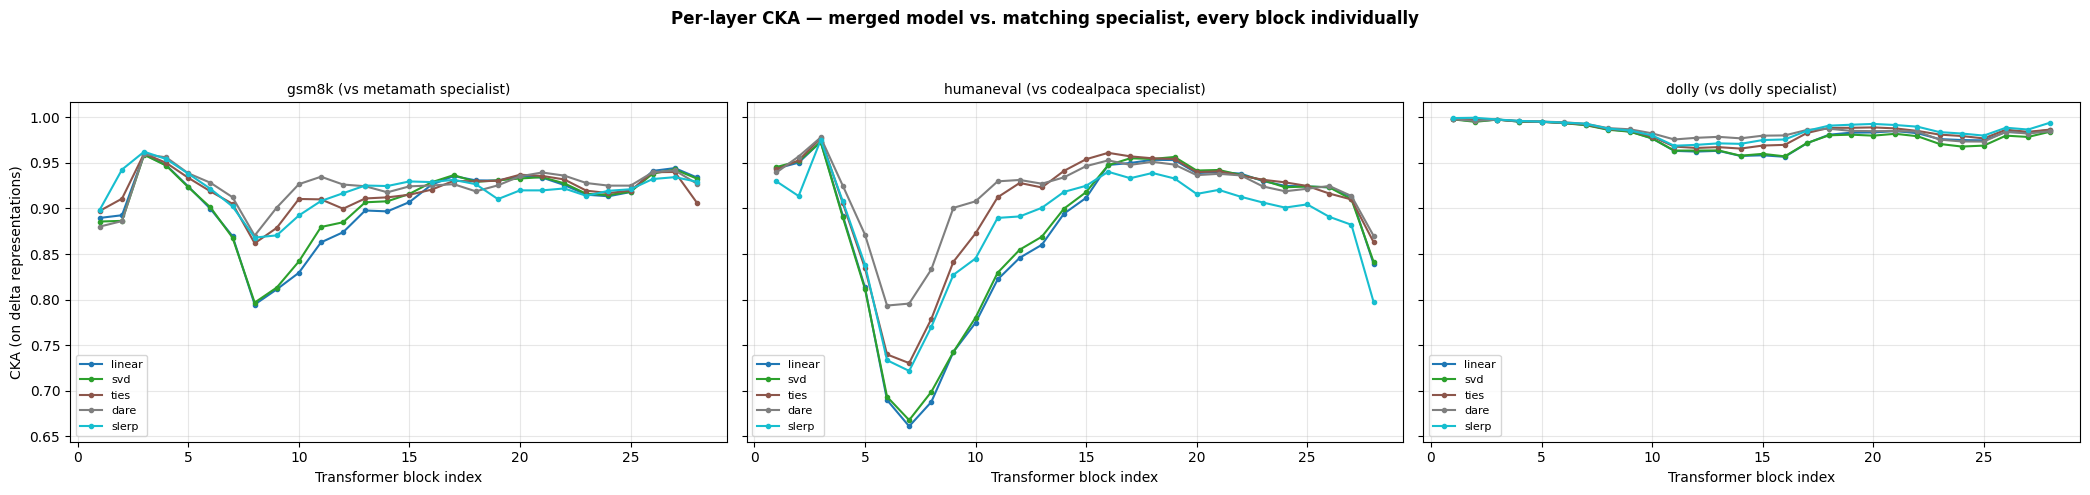

Saved: cka_per_layer_lineplot.png

Layers with the widest CKA spread across methods (most sensitive to merge choice):

  gsm8k:
    block 10  spread=0.0972  {'linear': 0.8295, 'svd': 0.8419, 'ties': 0.9104, 'dare': 0.9267, 'slerp': 0.8923}
    block 9   spread=0.0898  {'linear': 0.8112, 'svd': 0.8132, 'ties': 0.8787, 'dare': 0.9011, 'slerp': 0.8705}
    block 8   spread=0.0756  {'linear': 0.7946, 'svd': 0.7967, 'ties': 0.8618, 'dare': 0.8702, 'slerp': 0.868}
    block 11  spread=0.0721  {'linear': 0.8628, 'svd': 0.8797, 'ties': 0.91, 'dare': 0.9349, 'slerp': 0.9082}
    block 2   spread=0.0565  {'linear': 0.8926, 'svd': 0.8864, 'ties': 0.9108, 'dare': 0.8862, 'slerp': 0.9427}

  humaneval:
    block 9   spread=0.1581  {'linear': 0.7425, 'svd': 0.7425, 'ties': 0.8415, 'dare': 0.9007, 'slerp': 0.8271}
    block 8   spread=0.1455  {'linear': 0.6876, 'svd': 0.6986, 'ties': 0.7786, 'dare': 0.833, 'slerp': 0.7698}
    block 7   spread=0.1347  {'linear': 0.6609, 'svd': 0.6677, 'ties': 0.7303,

In [8]:
import matplotlib.pyplot as plt
import numpy as np

tasks = list(task_prompts.keys())
methods = list(results.keys())
n_layers = len(next(iter(results.values()))[tasks[0]])  # 28 (embedding excluded)
layer_x = list(range(1, n_layers + 1))  # transformer block indices 1..28

fig, axes = plt.subplots(1, len(tasks), figsize=(7 * len(tasks), 5), sharey=True)
if len(tasks) == 1:
    axes = [axes]

colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))

for ax, task in zip(axes, tasks):
    for method, color in zip(methods, colors):
        ax.plot(layer_x, results[method][task], marker='o', markersize=3,
                label=method, color=color, linewidth=1.5)
    ax.set_xlabel("Transformer block index")
    ax.set_title(f"{task} (vs {task_to_specialist_name[task]} specialist)", fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel("CKA (on delta representations)")
fig.suptitle("Per-layer CKA — merged model vs. matching specialist, every block individually",
             fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("cka_per_layer_lineplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cka_per_layer_lineplot.png")

# ── Flag layers with the widest spread across methods — where merge choice matters most ──
print("\nLayers with the widest CKA spread across methods (most sensitive to merge choice):")
for task in tasks:
    spreads = [max(results[m][task][i] for m in methods) - min(results[m][task][i] for m in methods)
               for i in range(n_layers)]
    top5 = sorted(range(n_layers), key=lambda i: -spreads[i])[:5]
    print(f"\n  {task}:")
    for i in top5:
        block_scores = {m: round(results[m][task][i], 4) for m in methods}
        print(f"    block {layer_x[i]:<3} spread={spreads[i]:.4f}  {block_scores}")


## NEW: Effective Rank / Singular Value Spectrum Per Adapter

Separate analysis — operates on the raw adapter deltas directly, not the merged models. Tests whether dolly/metamath/codealpaca actually need different amounts of their rank-16 budget.

In [9]:
from safetensors.torch import load_file
from huggingface_hub import hf_hub_download
import json
import torch

def get_lora_deltas(repo_name: str, hf_username: str = "Srishtik", lora_alpha: int = None, r: int = None) -> dict:
    repo_id = f"{hf_username}/{repo_name}"
    config_path = hf_hub_download(repo_id=repo_id, filename="adapter_config.json")
    cfg = json.load(open(config_path))
    actual_r     = r if r is not None else cfg.get("r")
    actual_alpha = lora_alpha if lora_alpha is not None else cfg.get("lora_alpha")
    path = hf_hub_download(repo_id=repo_id, filename="adapter_model.safetensors")
    adapter_weights = load_file(path)
    scale = actual_alpha / actual_r
    layers = {}
    for key, val in adapter_weights.items():
        if "lora_A" in key:
            base_key = key.replace("lora_A.default.weight", "").replace("lora_A.weight", "")
            layers.setdefault(base_key, {})["A"] = val.float()
        elif "lora_B" in key:
            base_key = key.replace("lora_B.default.weight", "").replace("lora_B.weight", "")
            layers.setdefault(base_key, {})["B"] = val.float()
    deltas = {}
    for base_key, mats in layers.items():
        if "A" in mats and "B" in mats:
            deltas[base_key] = scale * (mats["B"] @ mats["A"])
    print(f"  {repo_name:<35} r={actual_r}  alpha={actual_alpha}  scale={scale:.4f}")
    return deltas

print("Loading adapter deltas for singular value / effective rank analysis:")
dolly_deltas      = get_lora_deltas("qwen3-trained-on-dolly-15k")
metamath_deltas   = get_lora_deltas("qwen3-trained-on-metamath-15k")
codealpaca_deltas = get_lora_deltas("qwen3-trained-on-code-alpaca-18k")


Loading adapter deltas for singular value / effective rank analysis:
  qwen3-trained-on-dolly-15k          r=16  alpha=32  scale=2.0000
  qwen3-trained-on-metamath-15k       r=16  alpha=32  scale=2.0000
  qwen3-trained-on-code-alpaca-18k    r=16  alpha=32  scale=2.0000


Effective rank (entropy-based) across 196 layers — nominal rank is 16 for all three:

Adapter       mean erank       std     min     max   % of nominal-16
dolly            12.3732    1.7090  4.3987 15.0506             77.3%
metamath         14.3591    0.7031 11.3244 15.3488             89.7%
codealpaca       14.2404    0.8513 10.2576 15.4708             89.0%

Mean singular value spectrum (rank-1 to rank-16, averaged across 196 layers):
Rank           dolly      metamath    codealpaca
1             0.3068        0.5623        1.1984
2             0.1235        0.3946        0.7589
3             0.0940        0.3283        0.6220
4             0.0795        0.2911        0.5496
5             0.0707        0.2635        0.5019
6             0.0639        0.2411        0.4623
7             0.0585        0.2232        0.4286
8             0.0542        0.2073        0.4012
9             0.0502        0.1935        0.3780
10            0.0468        0.1807        0.3554
11            0.0437

/tmp/ipykernel_23/3093270557.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([erank_by_adapter[name] for name in adapters], labels=list(adapters.keys()))


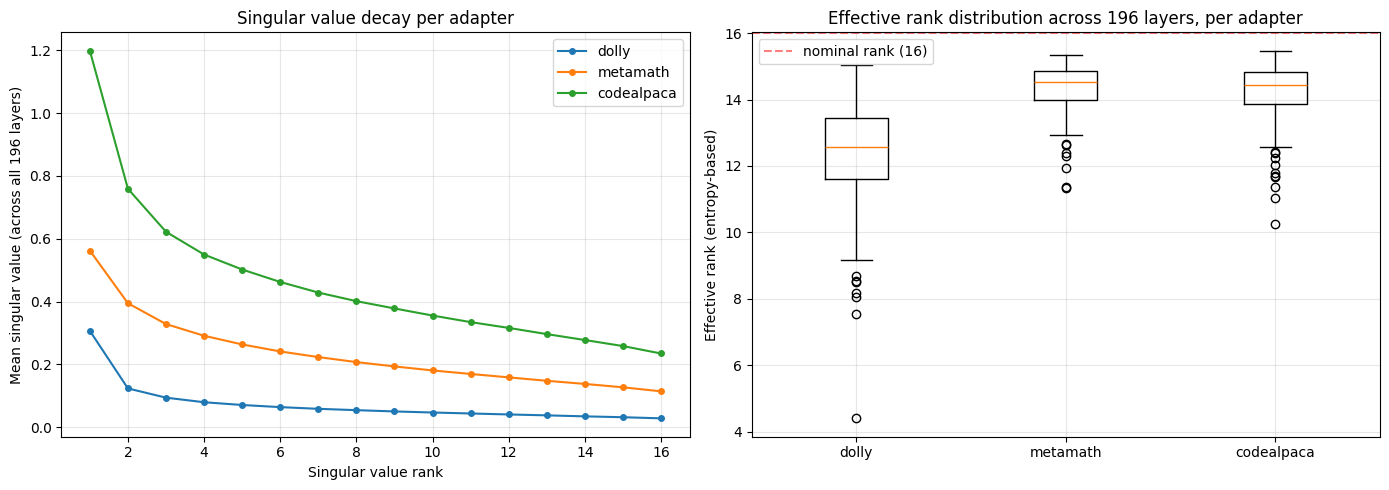


Saved: effective_rank_analysis.png

If one adapter's effective rank is consistently lower than the others,
it's using LESS of its rank-16 budget than the others -- meaning an equal
16/16/16 rank split (as BWSum currently does) may not be the right allocation;
an adapter with higher effective rank arguably needs more rank in a merge budget,
not an equal share.


In [10]:
import torch
import numpy as np

def effective_rank(matrix: torch.Tensor) -> float:
    """
    Entropy-based effective rank (Roy & Vetterli, 2007): erank = exp(H(p)),
    where p_i = s_i / sum(s) is the normalized singular value distribution
    and H is Shannon entropy. Unlike the nominal rank (fixed at 16 for every
    adapter by training config), this measures how many directions the
    matrix ACTUALLY uses — a matrix with one dominant singular value and 15
    near-zero ones has erank close to 1, even though its nominal rank is 16.
    """
    S = torch.linalg.svdvals(matrix.float())
    S = S[S > 1e-10]
    if len(S) == 0:
        return 0.0
    p = S / S.sum()
    entropy = -(p * torch.log(p)).sum()
    return torch.exp(entropy).item()


def singular_value_spectrum(matrix: torch.Tensor, n: int = 16) -> list:
    S = torch.linalg.svdvals(matrix.float())
    return S[:n].tolist()


keys = list(set(dolly_deltas.keys()) & set(metamath_deltas.keys()) & set(codealpaca_deltas.keys()))
adapters = {"dolly": dolly_deltas, "metamath": metamath_deltas, "codealpaca": codealpaca_deltas}

# ── Effective rank per adapter, aggregated across all 196 layers ──
erank_by_adapter = {name: [] for name in adapters}
for key in keys:
    for name, deltas in adapters.items():
        erank_by_adapter[name].append(effective_rank(deltas[key]))

print(f"Effective rank (entropy-based) across {len(keys)} layers — nominal rank is 16 for all three:\n")
print(f"{'Adapter':<12}{'mean erank':>12}{'std':>10}{'min':>8}{'max':>8}{'% of nominal-16':>18}")
for name in adapters:
    vals = np.array(erank_by_adapter[name])
    print(f"{name:<12}{vals.mean():>12.4f}{vals.std():>10.4f}{vals.min():>8.4f}{vals.max():>8.4f}"
          f"{100*vals.mean()/16:>17.1f}%")

# ── Singular value spectrum, averaged across layers, per adapter ──
print(f"\nMean singular value spectrum (rank-1 to rank-16, averaged across {len(keys)} layers):")
spectra = {name: np.zeros(16) for name in adapters}
for key in keys:
    for name, deltas in adapters.items():
        sv = singular_value_spectrum(deltas[key], n=16)
        spectra[name][:len(sv)] += np.array(sv)
for name in adapters:
    spectra[name] /= len(keys)

print(f"{'Rank':<6}" + "".join(f"{name:>14}" for name in adapters))
for i in range(16):
    print(f"{i+1:<6}" + "".join(f"{spectra[name][i]:>14.4f}" for name in adapters))

# ── Plot ──
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name in adapters:
    axes[0].plot(range(1, 17), spectra[name], marker='o', markersize=4, label=name)
axes[0].set_xlabel("Singular value rank")
axes[0].set_ylabel("Mean singular value (across all 196 layers)")
axes[0].set_title("Singular value decay per adapter")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].boxplot([erank_by_adapter[name] for name in adapters], labels=list(adapters.keys()))
axes[1].axhline(16, color="red", linestyle="--", alpha=0.5, label="nominal rank (16)")
axes[1].set_ylabel("Effective rank (entropy-based)")
axes[1].set_title("Effective rank distribution across 196 layers, per adapter")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("effective_rank_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: effective_rank_analysis.png")

print("\nIf one adapter's effective rank is consistently lower than the others,")
print("it's using LESS of its rank-16 budget than the others -- meaning an equal")
print("16/16/16 rank split (as BWSum currently does) may not be the right allocation;")
print("an adapter with higher effective rank arguably needs more rank in a merge budget,")
print("not an equal share.")
